### 🌐 한국어에 BERTopic 적용하기
BERTopic을 한국어에 적용하기 위해서는 몇 가지 추가적인 설정이 필요합니다. 이유는 다음과 같습니다:

1) 기본적으로 CountVectorizer는 띄어쓰기 기반의 단어 분할만 지원하므로,

형태소 단위 분석이 중요한 한국어에는 적절하지 않습니다.

2) 문서 임베딩에 사용하는 기본 모델은 영어에 최적화된 SBERT이므로,

한국어 문장 표현을 잘 반영하는 다국어 모델로 변경해야 합니다.

✅ 주요 설정 변경 요약

- 형태소 분석기 Kkma 사용

CountVectorizer 대신 한국어 형태소 분석을 통해 단어 토큰화

- 다국어 SBERT 모델 사용

예: sentence-transformers/distiluse-base-multilingual-cased-v1

In [ ]:
# 3분 정도 소요
!pip install bertopic[visualization]

# Kiwi 형태소 분석기
!pip install -q kiwipiepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

## 1. 데이터 다운로드

https://www.kci.go.kr/kciportal/main.kci

0) 우측 상단의 로그인 탭으로 이동해 로그인을 진행한다.
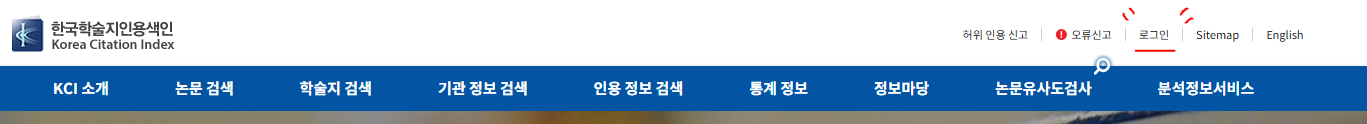

1) 원하는 키워드로 논문을 검색한다.

2) 원하는 조건에 맞게 선택항목 재검색을 한다.

3) '모두 선택(한 페이지에 최대 300개씩 보기 가능)'

& '서지정보 내보내기'를 통해 한 페이지씩 다운로드 받는다.


`샘플 파일`

: 'LLM'(Large Language Model)을 포함한 2023 ~ 2025년 논문

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/main/LLM_KCI.xls
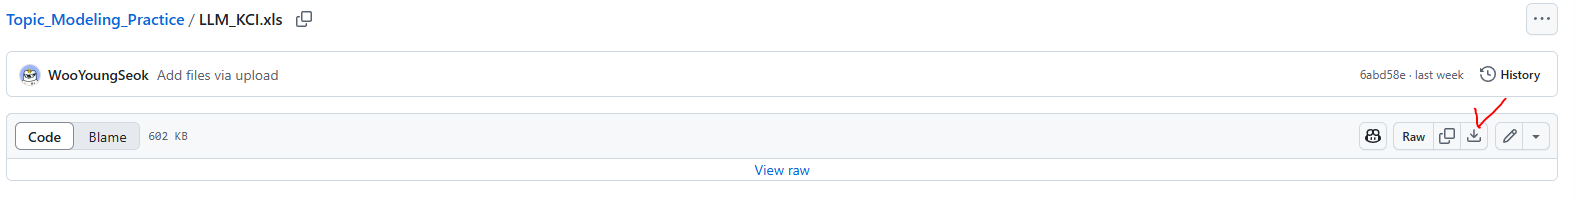

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/main/LLM_KCI_2.xls



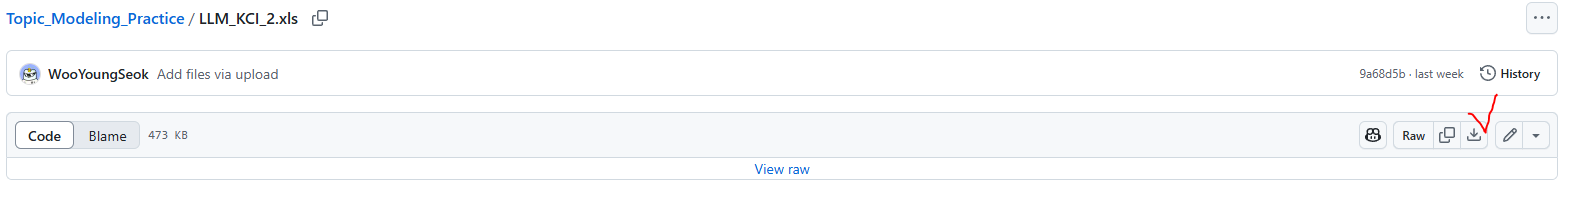
둘다 'download the raw file' 클릭



In [ ]:
import pandas as pd

data = pd.read_excel('/content/LLM_KCI.xls')
print('논문 개수 :',len(data))

논문 개수 : 300


In [ ]:
import pandas as pd
data2 = pd.read_excel('/content/LLM_KCI_2.xls')

# 두개 파일 합치기
data = pd.concat([data, data2], ignore_index=True)
print('논문 개수 :',len(data))

논문 개수 : 504


In [ ]:
# 데이터 확인
data.head(5)

,유형,저자명,주저자 소속기관,논문명,학술지명,저자키워드,초록,발행기관명,발행연도,주제분야,반출일
0,J,김승현;이상진,고려대학교,LLM을 활용한 SQL Injection 퍼징 연구,정보보호학회논문지,"LLM, SQL Injection, Mutation, Detection",최근 대규모 언어 모델(LLM)의 발전은 코드 수준의 맥락 이해와 생성 능력을 바탕...,한국정보보호학회,2025,컴퓨터학,2025-07-10
1,J,이찬우;허준영,한성대학교,경량화 LLM 기반 시큐어 코딩 지원,정보처리학회 논문지,"시큐어 코딩, 모델 경량화, 대규모 언어 모델(LLM)","IT 산업에서 보안의 중요성이 증가함에 따라, 시큐어 코딩은 필수적이다. 하지만 소...",한국정보처리학회,2025,컴퓨터학,2025-07-10
2,J,진현준;최정원;조용권;홍영창;이동수;신우빈;박후린,세종대학교,RAG와 OCR 기술을 활용한 LLM 기반 정보보호 관리체계(ISMS) 인증관리 자...,정보보호학회논문지,"ISMS, LLM, RAG, OCR, Automation",본 연구는 기업이 정보보호 관리체계(ISMS) 인증심사를 준비함에 있어 복잡한 규제...,한국정보보호학회,2025,컴퓨터학,2025-07-10
3,J,박해세;이동건;서영석,영남대학교 컴퓨터공학과,LLM 기반의 소비자 리뷰 분석을 통한 상품 판매 전략 지원,정보처리학회 논문지,"LLM, OCR, 데이터 공학, 소비자 심리, 심리학, 웹 스크래핑, 웹 크롤링, ...",온라인 쇼핑의 확산으로 상품 리뷰는 소비자 구매 결정에 중요한 영향을 미치고 있다....,한국정보처리학회,2025,컴퓨터학,2025-07-10
4,J,김호준;김현동;손서희;배성욱;옥지원;이세종,서울과학기술대학교,A Design and Implementation of Youth Profanity...,한국컴퓨터정보학회논문지,"생성형 AI, 사이버폭력, 비속어, LLM, RAG",본 논문에서는 청소년의 건전한 언어문화 형성과 사이버 폭력 예방을 위한 AI 기반의...,한국컴퓨터정보학회,2025,컴퓨터학,2025-07-10


In [ ]:
# 열 이름 출력
data.columns

Index(['유형', '저자명', '주저자 소속기관', '논문명', '학술지명', '저자키워드', '초록', '발행기관명', '발행연도',
       '주제분야', '반출일'],
      dtype='object')

In [ ]:
# 'Abstract' 열만 선택하여 새로운 DataFrame에 저장
# 이는 논문의 주제를 요약하기 위해 Abstract 내용만 사용하기 위함입니다.
abstract = data[['초록']]
abstract.head(5)

,초록
0,최근 대규모 언어 모델(LLM)의 발전은 코드 수준의 맥락 이해와 생성 능력을 바탕...
1,"IT 산업에서 보안의 중요성이 증가함에 따라, 시큐어 코딩은 필수적이다. 하지만 소..."
2,본 연구는 기업이 정보보호 관리체계(ISMS) 인증심사를 준비함에 있어 복잡한 규제...
3,온라인 쇼핑의 확산으로 상품 리뷰는 소비자 구매 결정에 중요한 영향을 미치고 있다....
4,본 논문에서는 청소년의 건전한 언어문화 형성과 사이버 폭력 예방을 위한 AI 기반의...


In [ ]:
# '초록' 컬럼의 결측값(NaN)을 제거합니다
abstract = abstract.dropna(subset=['초록'])

print('결측값 제거 후 논문 개수 :',len(abstract))

결측값 제거 후 논문 개수 : 500


In [ ]:
print('기존 총 문서의 수 :', len(data))

기존 총 문서의 수 : 504


## 2. 한국어 토크나이저와 SBERT를 이용한 Bertopic

In [ ]:
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer

from kiwipiepy import Kiwi

from bertopic import BERTopic

In [ ]:
# 설치 확인 및 임포트
kiwi = Kiwi()
print(kiwi.tokenize("자연어 처리는 정말 재미있어요"))

[Token(form='자연어 처리', tag='NNP', start=0, len=6), Token(form='는', tag='JX', start=6, len=1), Token(form='정말', tag='MAG', start=8, len=2), Token(form='재미있', tag='VA', start=11, len=3), Token(form='어요', tag='EF', start=14, len=2)]


In [ ]:
class CustomTokenizer:
    def __init__(self, tagger):
        self.tagger = tagger
    def __call__(self, text):
        tokens = kiwi.tokenize(text)
        # 한글자 단어 제거 => 일반적인 조사 제거
        nouns = [token.form for token in tokens if token.tag in ("NNG", "NNP")]
        return nouns

custom_tokenizer = CustomTokenizer(Kiwi())

In [ ]:
vectorizer = CountVectorizer(tokenizer=custom_tokenizer, max_features=3000)

In [ ]:
# 임베딩 모델로 다국어 SBERT 사용
model = BERTopic(embedding_model="sentence-transformers/xlm-r-100langs-bert-base-nli-stsb-mean-tokens", \
                 vectorizer_model=vectorizer,
                 top_n_words=10,
                 calculate_probabilities=True)

In [ ]:
# 5분 미만 소요
topics, probabilities = model.fit_transform(abstract['초록'])

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
model.save("my_korean_topics_model", serialization='safetensors') # 한국어 토크나이저의 경우 pickle과 호환이 안됨

### 저장된 model 사용 시, 아래 코드 주석해제
# BerTopic_model = BERTopic.load("my_korean_topics_model")

## 3. 토픽 시각화
- 동일한 데이터셋이라도 토픽 주제 수와 핵심표현에 차이가 있을 수 있음

In [ ]:
model.get_topic_info()
# 토픽의 개수, 토픽의 크기, 각 토픽에 할당된 단어들을 일부 확인 가능

,Topic,Count,Name,Representation,Representative_Docs
0,-1,135,-1_연구_모델_활용_생성,"[연구, 모델, 활용, 생성, 데이터, 정보, 기반, 기술, 언어, 결과]",[본 논문은 최근 주목받고 있는 검색 증강 생성(RAG) 시스템의 성능 평가를 위한...
1,0,114,0_교육_연구_평가_학습,"[교육, 연구, 평가, 학습, 활용, 모델, 언어, 생성, 결과, 분석]",[본 연구는 교육 현장에서 대규모 언어 모델(LLM) 기반 AI 에이전트의 활용 가...
2,1,105,1_모델_연구_기반_성능,"[모델, 연구, 기반, 성능, 생성, 언어, 분석, 데이터, 제안, 검색]",[LLM은 학습 데이터에 포함되지 않은 최신 정보나 특정 도메인 지식 부족으로 인해...
3,2,92,2_데이터_연구_활용_모델,"[데이터, 연구, 활용, 모델, 생성, 기업, 기술, 분석, 언어, 기반]","[본 연구의 목적은 본 연구는 인공지능(AI) 기술, 특히 생성형 AI가 회계 프로..."
4,3,36,3_의료_정보_시스템_상담,"[의료, 정보, 시스템, 상담, 치과, 처리, 국외, 치안, 기관, 데이터]",[본 연구는 대규모 언어 모델(LLM) 기반의 Private LLM을 활용하여 의료...
5,4,18,4_디자인_이미지_기술_생성,"[디자인, 이미지, 기술, 생성, 활용, 연구, 구축, 기반, 데이터, 도면]",[본 연구는 최근 등장한 AI 기반 이미지 생성 도구가 컴퓨터 디자인 과업수행에 미...


In [ ]:
# 주제간 거리 그래프
# -1 토픽을 제외하고 유의미한 토픽이 2개라면, 시각화 안됨
model.visualize_topics()

In [ ]:
# 토픽 간 유사도 시각화
model.visualize_heatmap()